In [1]:
#训练数据提取
import warnings
warnings.simplefilter("ignore")
from prepare import train_properties_and_names

import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

train_properties, feature_names = train_properties_and_names()
dataset_path = 'data_filled_400.csv'

# read dataset
datas = pd.read_csv(dataset_path)
data = datas.drop(['element1','element2','NO(%)'],axis=1)
target = datas['NO(%)']

In [2]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(data, target, test_size=0.2, random_state=352)


In [3]:
from xgboost import XGBRegressor
xgb = XGBRegressor()

In [4]:
from prepare import process_regressor, model_performance_metrics,draw_scatter

In [5]:
train_pred, test_pred = process_regressor(xgb, x_train, x_test, y_train, y_test)

cv train R2: 0.472 (+/- 0.120) 



In [6]:
from sklearn.utils import resample
from sklearn.base import clone
import numpy as np

def bootstrap_predict_ci(model, X_train, y_train, X_val,
                         n_boot=1000, alpha=0.05, random_state=None):


    rng = np.random.RandomState(random_state)
    preds = []

    for i in range(n_boot):
        # 1. bootstrap采样（加随机种子）
        X_bs, y_bs = resample(
            X_train, y_train,
            replace=True,
            random_state=rng.randint(0, 1_000_000)
        )

        # 2. 克隆模型（关键！避免覆盖原模型）
        model_bs = clone(model)

        # 3. 训练
        model_bs.fit(X_bs, y_bs)

        # 4. 预测
        y_pred = model_bs.predict(X_val)

        preds.append(y_pred)

    preds = np.array(preds)

    # ===== 统计量 =====
    mean_pred = preds.mean(axis=0)
    lower = np.percentile(preds, 100 * (alpha / 2), axis=0)
    upper = np.percentile(preds, 100 * (1 - alpha / 2), axis=0)
    ci_width = upper - lower
    print("平均CI宽度:", np.mean(ci_width))
    return mean_pred, lower, upper, preds

In [53]:
mean_pred, lower, upper, preds = bootstrap_predict_ci(
    xgb,
    x_train, y_train,
    x_test,
    n_boot=3,
    alpha=0.05,
    random_state=42
)


平均CI宽度: 9.060189


In [55]:
y_test

array([59.73, 28.89, 91.4 , 31.4 , 27.1 , 36.43, 39.5 , 37.48, 76.34,
       31.5 , 36.3 , 31.26, 27.69, 39.72, 18.2 , 46.1 , 57.  , 31.9 ,
       19.14, 30.67, 25.64, 38.  , 25.81, 83.55, 58.83, 29.9 , 39.5 ,
       21.6 , 55.6 , 14.83, 40.1 , 73.3 , 35.45, 37.5 , 43.1 , 23.1 ,
       76.04, 74.85, 59.7 , 39.02, 78.5 , 39.01, 41.51, 18.5 , 26.01,
       20.22, 35.  , 39.1 , 43.4 ])

In [134]:
from catboost import CatBoostRegressor
catboost = CatBoostRegressor(l2_leaf_reg= 3,learning_rate=0.05,depth=5,iterations = 900,random_state=0,verbose=False)
mean_pred, lower, upper, preds = bootstrap_predict_ci(
    catboost,
    x_train, y_train,
    x_test,
    n_boot=30,
    alpha=0.05,
    random_state=42
)


平均CI宽度: 15.913165132673136


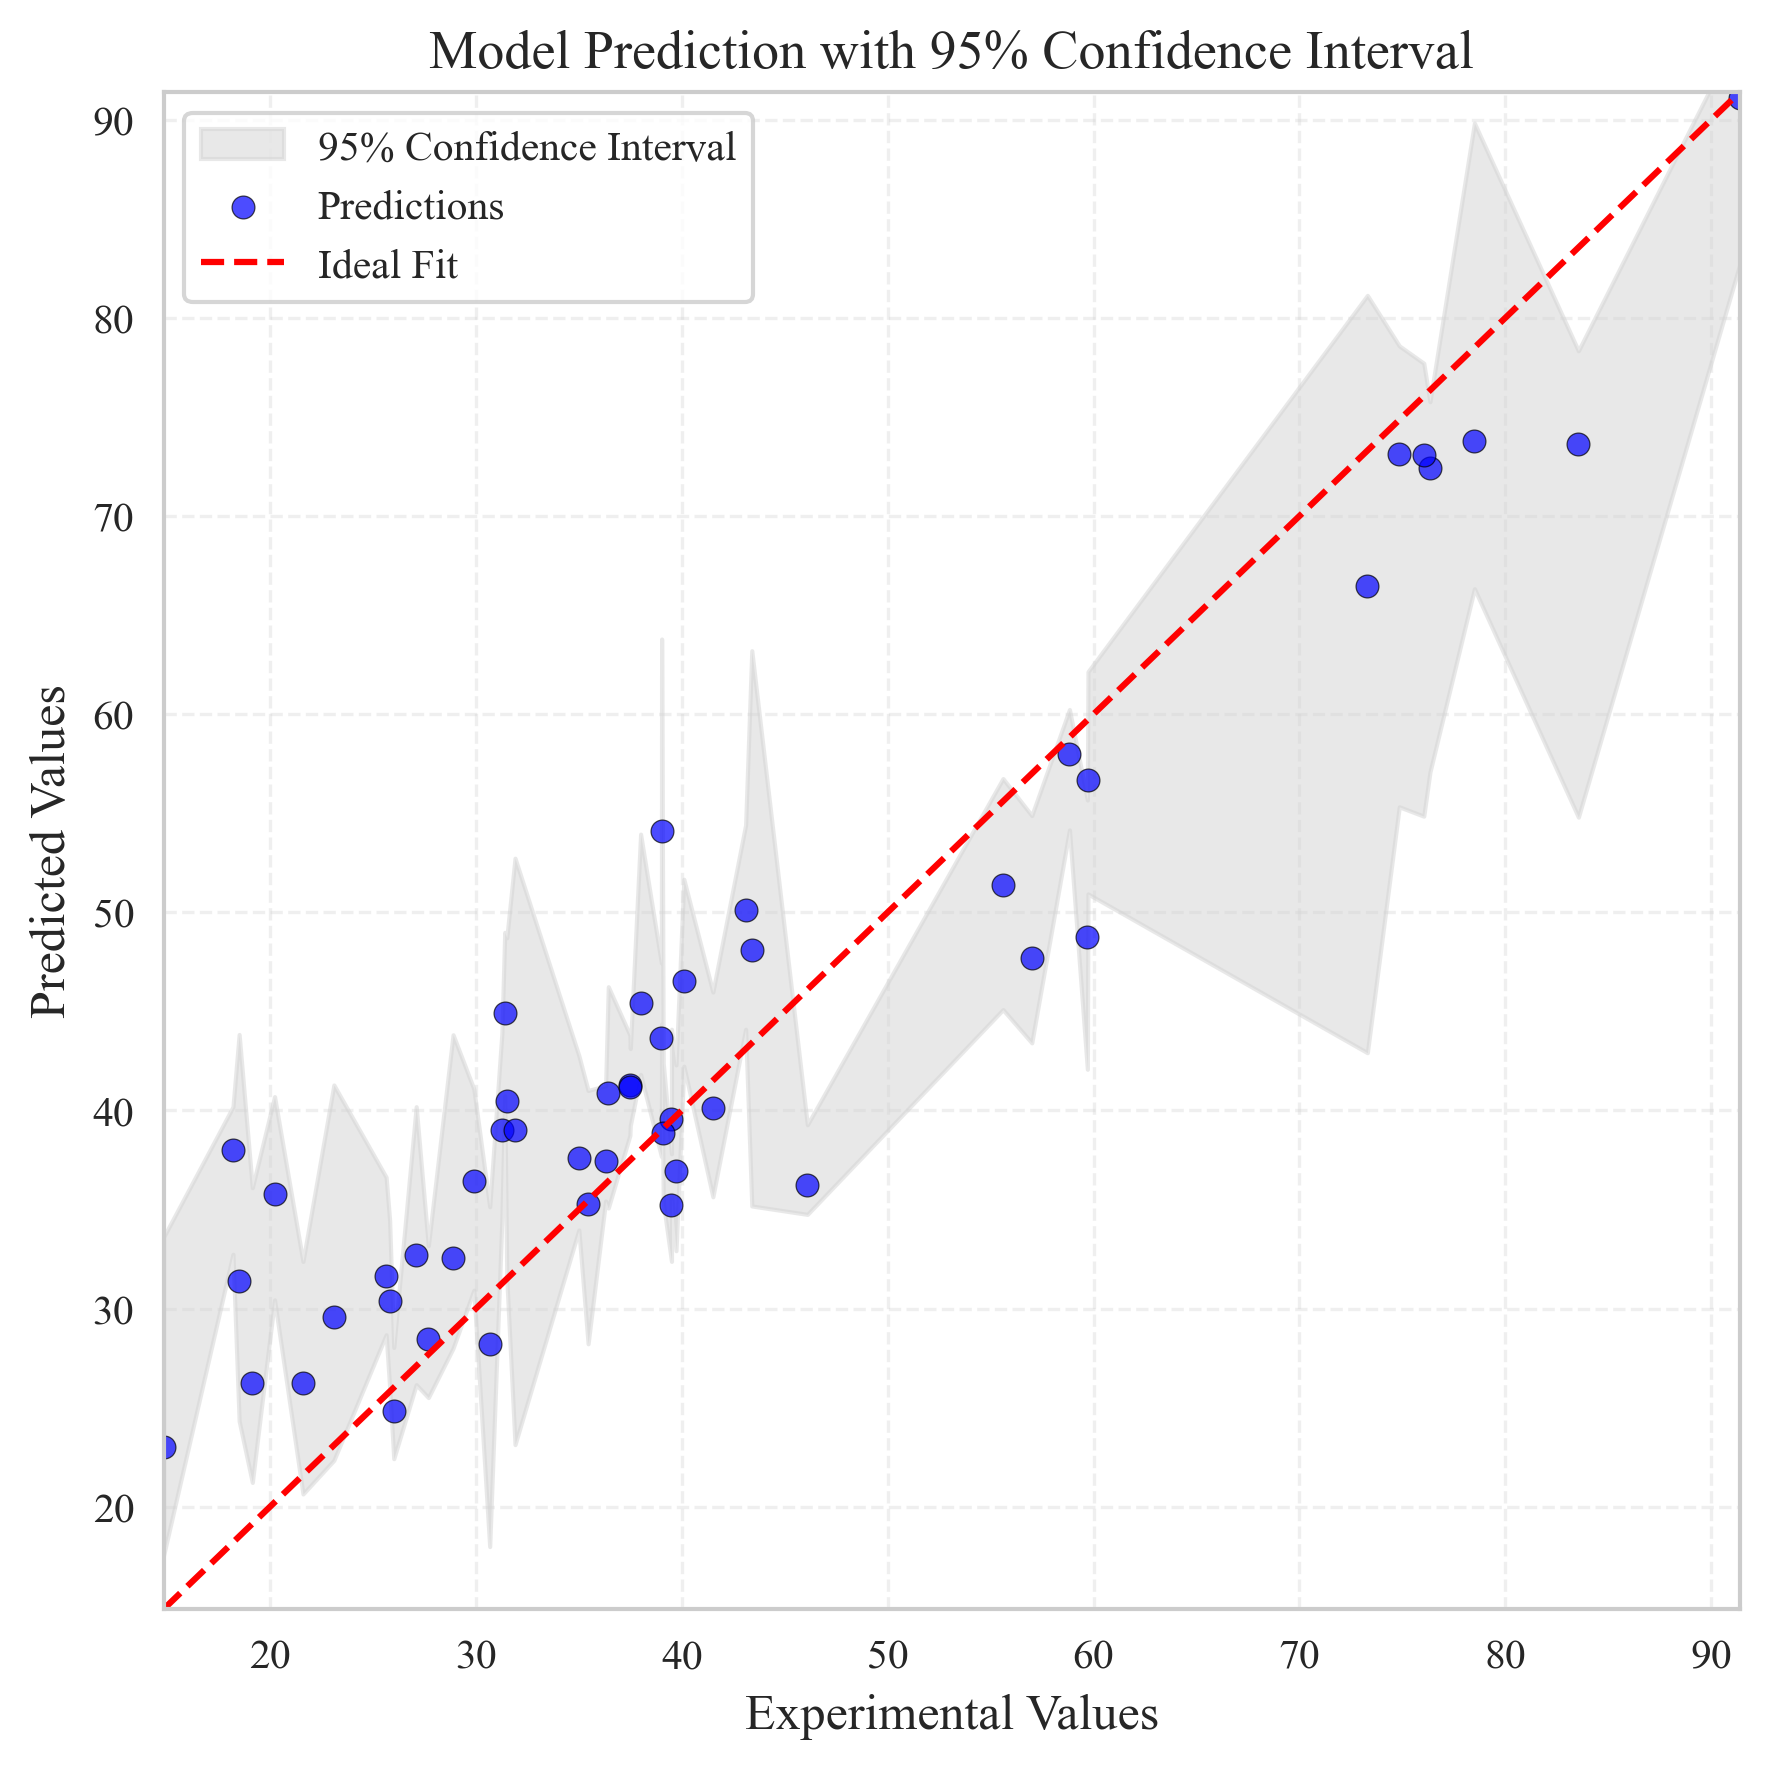

In [42]:
import numpy as np
import matplotlib.pyplot as plt

# ===== 排序（关键！保证阴影连续）=====
y_test = y_test # 👈关键

sorted_idx = np.argsort(y_test)

y_test_sorted = y_test[sorted_idx]
mean_pred_sorted = mean_pred[sorted_idx]
lower_sorted = lower[sorted_idx]
upper_sorted = upper[sorted_idx]
# ===== 画图 =====
plt.figure(figsize=(6, 6), dpi=300)

# 1️⃣ 置信区间阴影（SCI关键元素）
plt.fill_between(
    y_test_sorted,
    lower_sorted,
    upper_sorted,
    color='lightgray',
    alpha=0.5,
    label='95% Confidence Interval'
)

# 2️⃣ 预测点
plt.scatter(
    y_test,
    mean_pred,
    color='blue',
    s=30,
    alpha=0.7,
    edgecolor='k',
    linewidth=0.3,
    label='Predictions'
)

# 3️⃣ 理想对角线
min_val = min(y_test.min(), mean_pred.min())
max_val = max(y_test.max(), mean_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    'r--',
    linewidth=1.5,
    label='Ideal Fit'
)

# ===== 坐标 & 标签 =====
plt.xlabel("Experimental Values", fontsize=12)
plt.ylabel("Predicted Values", fontsize=12)

plt.title("Model Prediction with 95% Confidence Interval", fontsize=13)

# ===== 统一坐标范围（SCI推荐）=====
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)

# ===== 图例 =====
plt.legend(frameon=True, fontsize=10)

# ===== 网格（可选，SCI常用淡网格）=====
plt.grid(alpha=0.3, linestyle='--')

# ===== 边框加粗（更像论文）=====
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1)

plt.tight_layout()
plt.show()

In [98]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import interp1d
def draw_scatter_with_ci(train_true, train_pred, test_true, test_pred, title,
                         mean_pred, lower, upper, actual_text='actual', pred_text='prediction', save=False):
    # 统一字体设置
    plt.rcParams['font.family'] = 'Times New Roman'

    # 设置字体样式
    font_common = {
        'family': 'Times New Roman',
        'color': '#2F4F4F',  # 深灰色
        'weight': 'bold',
        'size': 18
    }

    # 确保输入是1D数组
    test_true = np.ravel(test_true)
    test_pred = np.ravel(test_pred)
    train_true = np.ravel(train_true)
    train_pred = np.ravel(train_pred)
    mean_pred = np.ravel(mean_pred)
    lower = np.ravel(lower)  # 置信区间下限
    upper = np.ravel(upper)  # 置信区间上限
    # 使用插值平滑置信区间
    interpolator_lower = interp1d(test_true, lower, kind='cubic', fill_value="extrapolate")
    interpolator_upper = interp1d(test_true, upper, kind='cubic', fill_value="extrapolate")
    lower_smooth = interpolator_lower(test_true)
    upper_smooth = interpolator_upper(test_true)
    # 绘制散点图
    sns.regplot(x=test_true, y=test_pred, color="orange", label="test")
    sns.regplot(x=train_true, y=train_pred, color="dodgerblue", label="train")

    # 添加置信区间的阴影面积（无标签，避免显示在图例中）
    plt.fill_between(test_true, lower_smooth, upper_smooth, color='orange', alpha=0.3, label="Confidence Interval Area")


    # 添加误差棒
    plt.errorbar(test_true, mean_pred, yerr=[mean_pred - lower, upper - mean_pred], fmt='o', color='orange', 
                 alpha=0.5, markersize=5)  # 移除了"Confidence Interval"标签

    # 设置坐标轴标签和范围
    plt.xlabel(actual_text, fontdict=font_common, weight='bold')
    plt.ylabel(pred_text, fontdict=font_common, weight='bold')
    plt.xlim(0, 100)
    plt.ylim(0, 100)

    # 设置图例，只显示 "Train" 和 "Test"
    legend_font = {'family': 'Times New Roman', 'weight': 'bold', 'size': 15}
    plt.legend(loc="upper right", markerscale=1.5, prop=legend_font, frameon=True, bbox_to_anchor=(0.3, 1))

    # 获取图中绘制的图
    ax = plt.gca()

    # 设置主刻度线 - 更明显的显示
    ax.tick_params(
        axis='both',  # 同时设置x轴和y轴
        which='major',  # 主刻度线
        direction='out',  # 刻度线方向：向内
        length=8,  # 增加刻度线长度
        width=2,  # 增加刻度线宽度
        color='black',  # 刻度线颜色
        labelsize=14,  # 标签大小
        bottom=True,  # 显示底部刻度线
        left=True,  # 显示左侧刻度线
        top=False,  # 显示顶部刻度线
        right=False  # 显示右侧刻度线
    )
    # 设置颜色
    ax.set_facecolor('white')

    # 设置边框
    for spine in ax.spines.values():
        spine.set_linewidth(2)
        spine.set_edgecolor('black')

    # 设置图内网格
    plt.grid(True,
             axis='both',
             linestyle='--',
             linewidth=0.5,
             color='gray',
             alpha=0.6)

    # 添加统计信息文本
    _, _, _, _, _, train_r2 = get_mse_rmse_mae_mape_smape_r2(train_true.ravel() / 100, train_pred / 100)
    _, test_rmse, _, _, _, test_r2 = get_mse_rmse_mae_mape_smape_r2(test_true.ravel() / 100, test_pred / 100)

    plt.text(60, 26, f"Train R² = {(int(train_r2 * 1000) / 1000):.3f}", **font_common)
    plt.text(60, 18, f"Test R² = {test_r2:.3f}", **font_common)
    plt.text(60, 10, f"RMSE = {test_rmse:.3f}", **font_common)

    # 添加标题
    plt.text(50, 90, title, **font_common, horizontalalignment="center")

    # 保存图像
    if save:
        out_put = 'scatter_images'
        if not os.path.exists(out_put):
            os.makedirs(out_put)
        output_path = os.path.join(out_put, f'{title}.jpg')
        plt.savefig(output_path, format="jpg", dpi=600,
                    bbox_inches="tight",
                    pil_kwargs={'quality': 95})
        print(f"测试图已保存：{output_path}")

    plt.show()

In [94]:
def model_performance_metrics(label, true, pred):
    mse, rmse, mae, mape, smape, r2 = get_mse_rmse_mae_mape_smape_r2(true.ravel() / 100, pred / 100)
    print("%s mse: %.5f | rmse: %.5f | mae: %.5f | mape: %.5f | smape: %.5f | r2: %.5f\n" % (
        label, mse, rmse, mae, mape, smape, r2))
    return r2
train_pred, test_pred = process_regressor(catboost, x_train, x_test, y_train, y_test)
model_performance_metrics('XGB Train', y_train, train_pred)
model_performance_metrics('XGB Test', y_test, test_pred)

cv train R2: 0.560 (+/- 0.051) 

XGB Train mse: 0.00015 | rmse: 0.01205 | mae: 0.00944 | mape: 2.35559 | smape: 2.33531 | r2: 0.99526

XGB Test mse: 0.00348 | rmse: 0.05896 | mae: 0.04727 | mape: 14.28829 | smape: 12.89395 | r2: 0.90103



0.9010281543618638

In [124]:
from catboost import CatBoostRegressor
catboost = CatBoostRegressor(l2_leaf_reg= 3,learning_rate=0.05,depth=5,iterations = 900,random_state=0,verbose=False)
mean_pred, lower, upper, preds = bootstrap_predict_ci(
    catboost,
    x_train, y_train,
    x_test,
    n_boot=10,
    alpha=0.05,
    random_state=42
)


平均CI宽度: 13.217825257490253


In [133]:
from catboost import CatBoostRegressor
catboost = CatBoostRegressor(verbose=False)
mean_pred, lower, upper, preds = bootstrap_predict_ci(
    catboost,
    x_train, y_train,
    x_test,
    n_boot=100,
    alpha=0.05,
    random_state=42
)

平均CI宽度: 15.489711741250177


In [141]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def draw_scatter_nature(train_true, train_pred,
                       test_true, test_pred,
                       mean_pred, lower, upper,
                       title):

    # ===== 1. 数据处理 =====
    train_true = np.ravel(train_true)
    train_pred = np.ravel(train_pred)
    test_true = np.ravel(test_true)
    test_pred = np.ravel(test_pred)
    mean_pred = np.ravel(mean_pred)
    lower = np.ravel(lower)
    upper = np.ravel(upper)

    # ===== 2. 画布 =====
    plt.figure(figsize=(6, 6), dpi=300)
    plt.rcParams['font.family'] = 'Arial'

    # ===== 4. 散点（核心）=====
    plt.scatter(train_true, train_pred,
                color='#1f77b4',
                s=30,
                alpha=0.8,
                label='Train')

    plt.scatter(test_true, test_pred,
                color='#ff7f0e',
                s=35,
                alpha=0.9,
                label='Test')

    # ===== 5. 回归线（干净版）=====
    sns.regplot(x=train_true, y=train_pred,
                scatter=False,
                color='#1f77b4',
                line_kws={'linewidth':2})

    sns.regplot(x=test_true, y=test_pred,
                scatter=False,
                color='#ff7f0e',
                line_kws={'linewidth':2})

    # ===== 6. 误差棒（重点：替代CI阴影）=====
    plt.errorbar(test_true, mean_pred,
                 yerr=[mean_pred - lower, upper - mean_pred],
                 fmt='none',
                 ecolor='#ff7f0e',
                 alpha=0.4,
                 elinewidth=1)

    # ===== 7. 坐标轴 =====
    plt.xlim(0, 100)
    plt.ylim(0, 100)

    plt.xlabel("Actual", fontsize=14)
    plt.ylabel("Predicted", fontsize=14)

    # ===== 8. 去掉多余元素（Nature风格关键）=====
    plt.grid(False)

    ax = plt.gca()
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)

    ax.tick_params(width=1.5, length=5)

    # ===== 9. 指标文本 =====
    _, _, _, _, _, train_r2 = get_mse_rmse_mae_mape_smape_r2(train_true/100, train_pred/100)
    _, test_rmse, _, _, _, test_r2 = get_mse_rmse_mae_mape_smape_r2(test_true/100, test_pred/100)

    plt.text(5, 90, f"Train $R^2$ = {train_r2:.3f}", fontsize=12)
    plt.text(5, 82, f"Test $R^2$ = {test_r2:.3f}", fontsize=12)
    plt.text(5, 74, f"RMSE = {test_rmse:.3f}", fontsize=12)

    # ===== 10. 图例（简洁版）=====
    plt.legend(frameon=False, fontsize=11, loc='lower right')

    # ===== 11. 标题（可选）=====
    plt.title(title, fontsize=14)

    plt.tight_layout()
    plt.show()

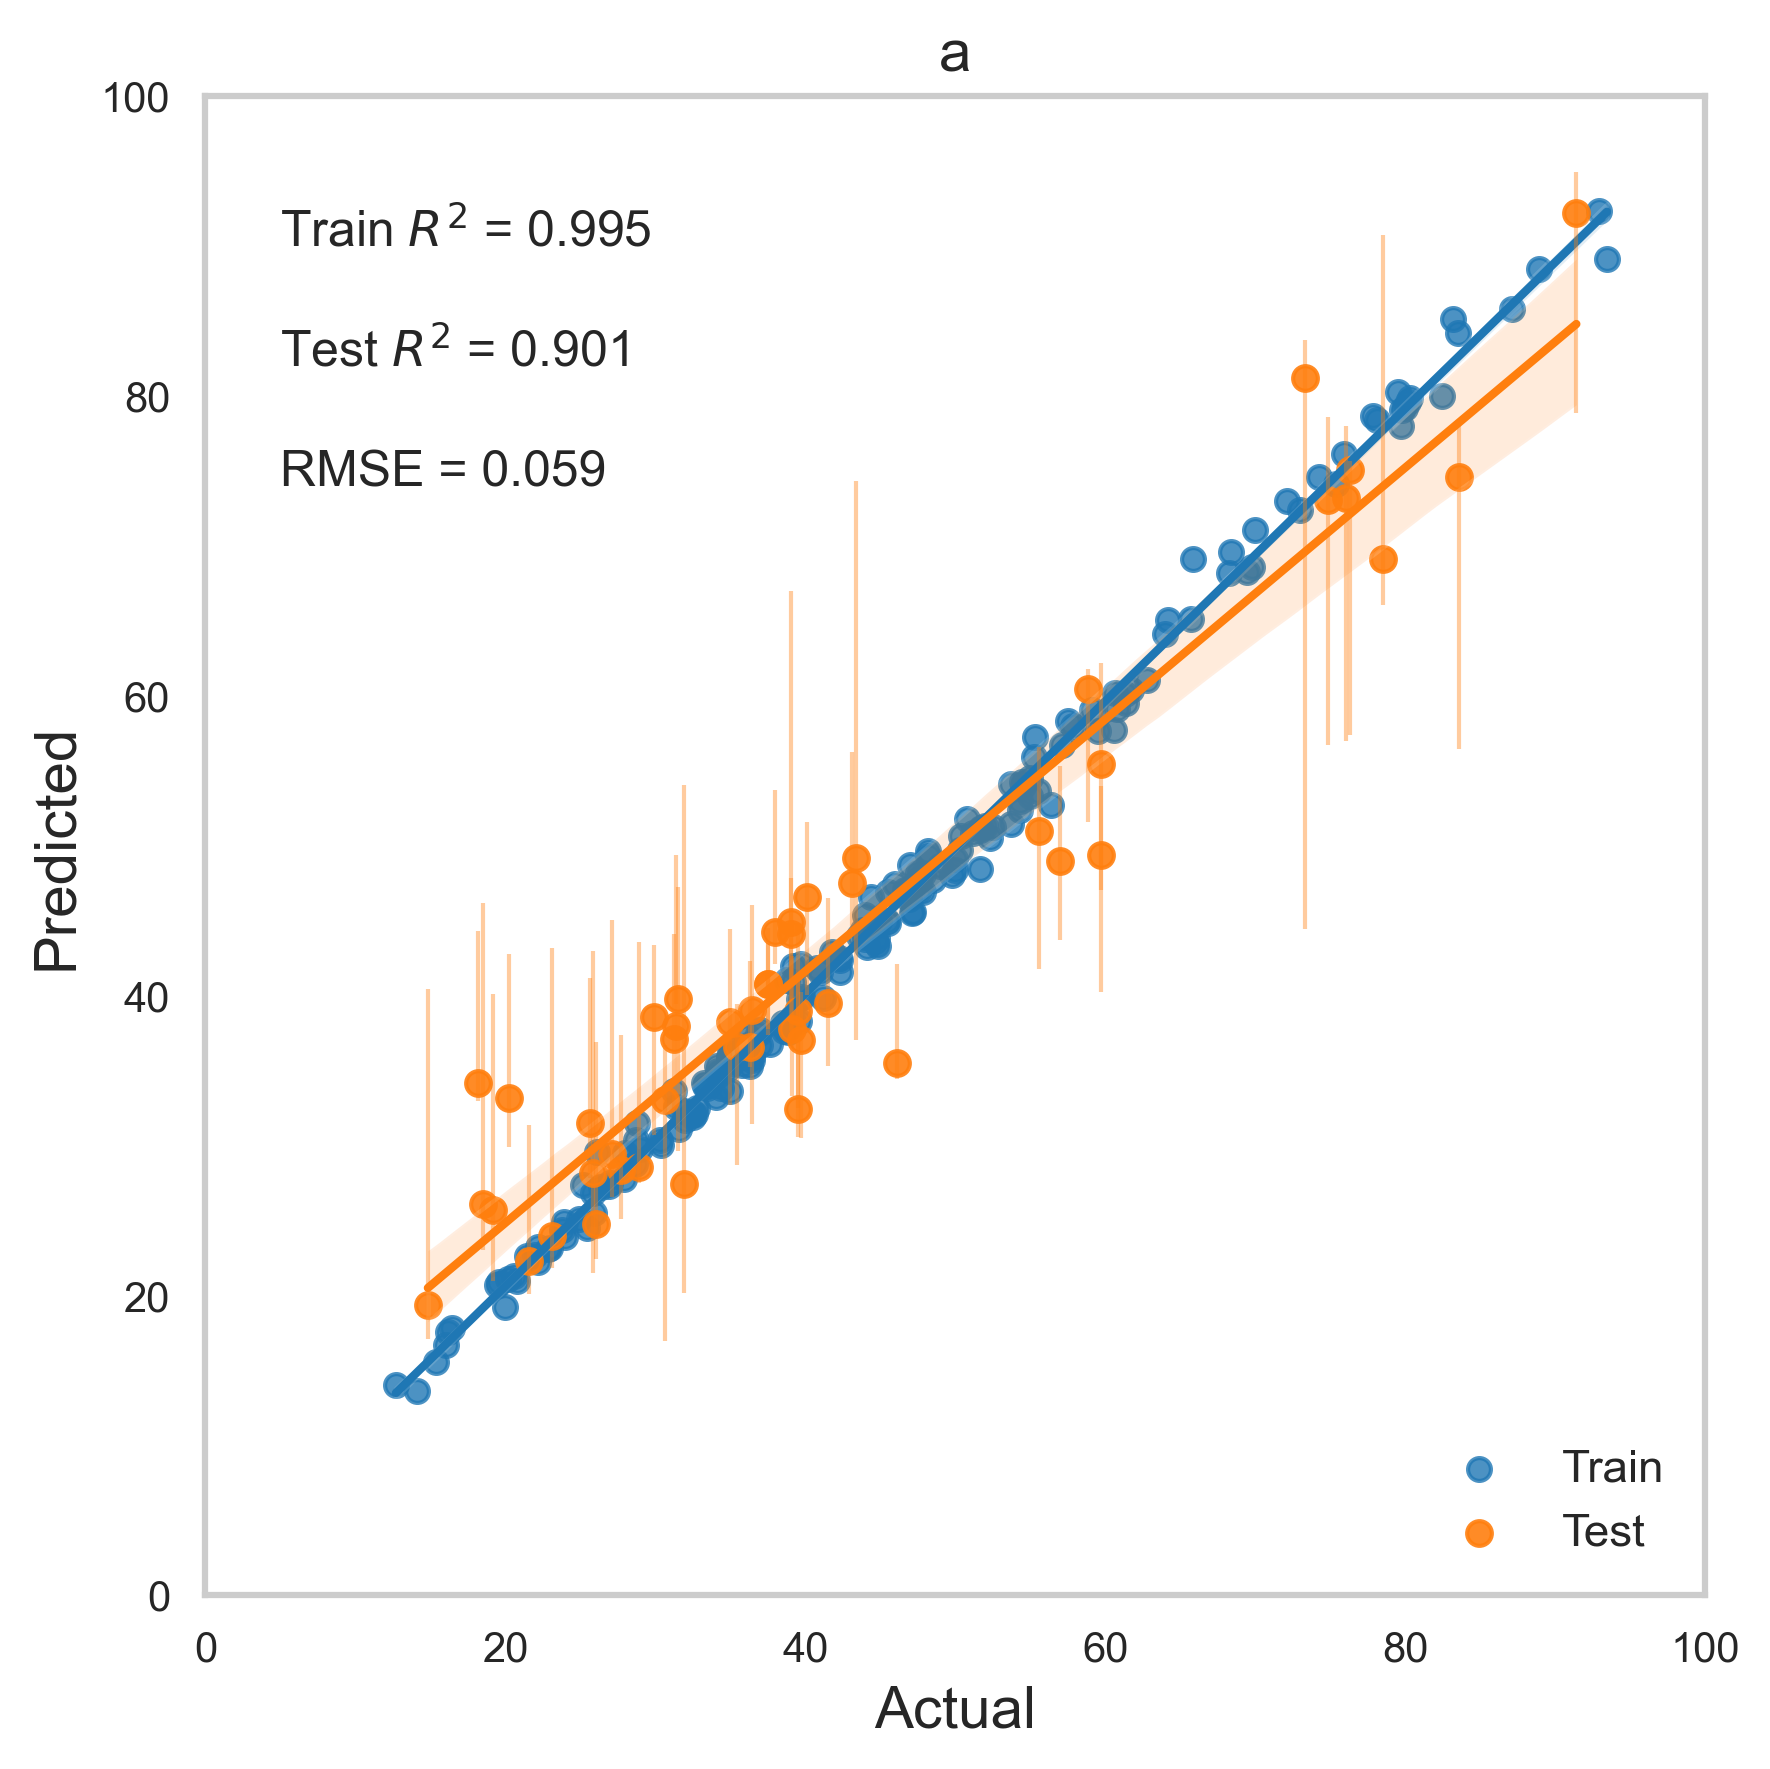

In [168]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def draw_scatter(train_true, train_pred,
                 test_true, test_pred,
                 title,
                 test_lower=None, test_upper=None,
                 train_lower=None, train_upper=None,
                 actual_text='actual', pred_text='prediction',
                 save=False):
    
    plt.rcParams['font.family'] = 'Times New Roman'

    font_common = {
        'family': 'Times New Roman',
        'color': '#2F4F4F',
        'weight': 'bold',
        'size': 18
    }
    plt.figure(figsize=(8, 6), dpi=600)
    # ===== 绘制散点 + 回归线 =====
    sns.regplot(x=test_true, y=test_pred, color="orange", label="test", scatter_kws={'s': 50, 'alpha': 0.7})
    sns.regplot(x=train_true, y=train_pred, color="dodgerblue", label="train", scatter_kws={'s': 50, 'alpha': 0.7})

    # 计算并排序预测结果和置信区间上下限
    sorted_idx = np.argsort(test_true)  # 按照测试数据排序（横轴）
    test_true_sorted = test_true[sorted_idx]
    test_pred_sorted = test_pred[sorted_idx]
    mean_pred_sorted = np.mean(test_pred)  # 如果有多次训练结果，可计算均值
    lower_sorted = test_lower[sorted_idx] if test_lower is not None else np.zeros_like(test_true_sorted)
    upper_sorted = test_upper[sorted_idx] if test_upper is not None else np.ones_like(test_true_sorted) * 100  # 默认100上限
    yerr_lower = np.maximum(test_pred_sorted - lower_sorted, 0)  # 保证误差下限为非负值
    yerr_upper = np.maximum(upper_sorted - test_pred_sorted, 0)  # 保证误差上限为非负值

    # ===== 绘制置信区间阴影 =====
    plt.fill_between(
        test_true_sorted,         # 横坐标为排序后的测试值
        lower_sorted,             # 置信区间下限
        upper_sorted,             # 置信区间上限
        color='lightgray',        # 置信区间颜色
        alpha=0.5,                # 透明度
        label='95% Confidence Interval'  # 图例标签
    )

    # ===== 绘制误差棒 =====
    if test_lower is not None and test_upper is not None:
        plt.errorbar(
            test_true_sorted, test_pred_sorted,
            yerr=[yerr_lower,yerr_upper],  # 误差棒上下限
            fmt='o',             # 画点
            ecolor='gray',       # 误差棒颜色
            alpha=0.6,           # 透明度
            capsize=3,           # 误差棒的帽子大小
            linewidth=1          # 误差棒宽度
        )

    # ===== 绘制理想拟合线（Ideal Fit） =====
    min_val = min(test_true.min(), test_pred.min())
    max_val = max(test_true.max(), test_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Ideal Fit')

    # ===== 以下保持你原有代码 =====
    plt.xlabel(actual_text, fontdict=font_common, weight='bold')
    plt.ylabel(pred_text, fontdict=font_common, weight='bold')

    # 统一坐标范围（与理想拟合线一致）
    plt.xlim(min_val, max_val)
    plt.ylim(min_val, max_val)

    legend_font = {'family': 'Times New Roman', 'weight': 'bold', 'size': 15}
    plt.legend(loc="lower right", markerscale=1.5, prop=legend_font, frameon=True)

    # 设置坐标轴
    ax = plt.gca()
    ax.tick_params(axis='both', which='major', direction='out', length=8, width=2, color='black', labelsize=14, bottom=True, left=True, top=False, right=False)
    ax.set_facecolor('white')
    plt.xticks(fontsize=14, fontweight='bold', family='Times New Roman')
    plt.yticks(fontsize=14, fontweight='bold', family='Times New Roman')
    for spine in ax.spines.values():
        spine.set_linewidth(2)
        spine.set_edgecolor('black')

    # 显示网格
    plt.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.6)

    # ===== 显示统计信息 =====
    _, _, _, _, _, train_r2 = get_mse_rmse_mae_mape_smape_r2(train_true.values.ravel() / 100, train_pred / 100)
    _, test_rmse, _, _, _, test_r2 = get_mse_rmse_mae_mape_smape_r2(test_true.ravel() / 100, test_pred / 100)

    # 设置标题和统计信息的显示位置
    x_range = max_val - min_val
    
    x_text = min_val + 0.05 * x_range
    y_text = max_val - 0.15 * x_range
    
    plt.text(x_text, y_text, f"Train R² = {train_r2:.3f}", **font_common)
    plt.text(x_text, y_text - 0.08*x_range, f"Test R² = {test_r2:.3f}", **font_common)
    plt.text(x_text, y_text - 0.16*x_range, f"RMSE = {test_rmse:.3f}", **font_common)
    plt.text(50, 88, title, **font_common, horizontalalignment="center")

    # ===== 保存图像 =====
    if save:
        out_put = 'scatter_images'
        if not os.path.exists(out_put):
            os.makedirs(out_put)
        output_path = os.path.join(out_put, f'{title}.jpg')
        plt.savefig(output_path, dpi=600, bbox_inches="tight", pil_kwargs={'quality': 95})

    # 显示图像
    plt.tight_layout()  # 确保所有元素适配在图中
    plt.show()

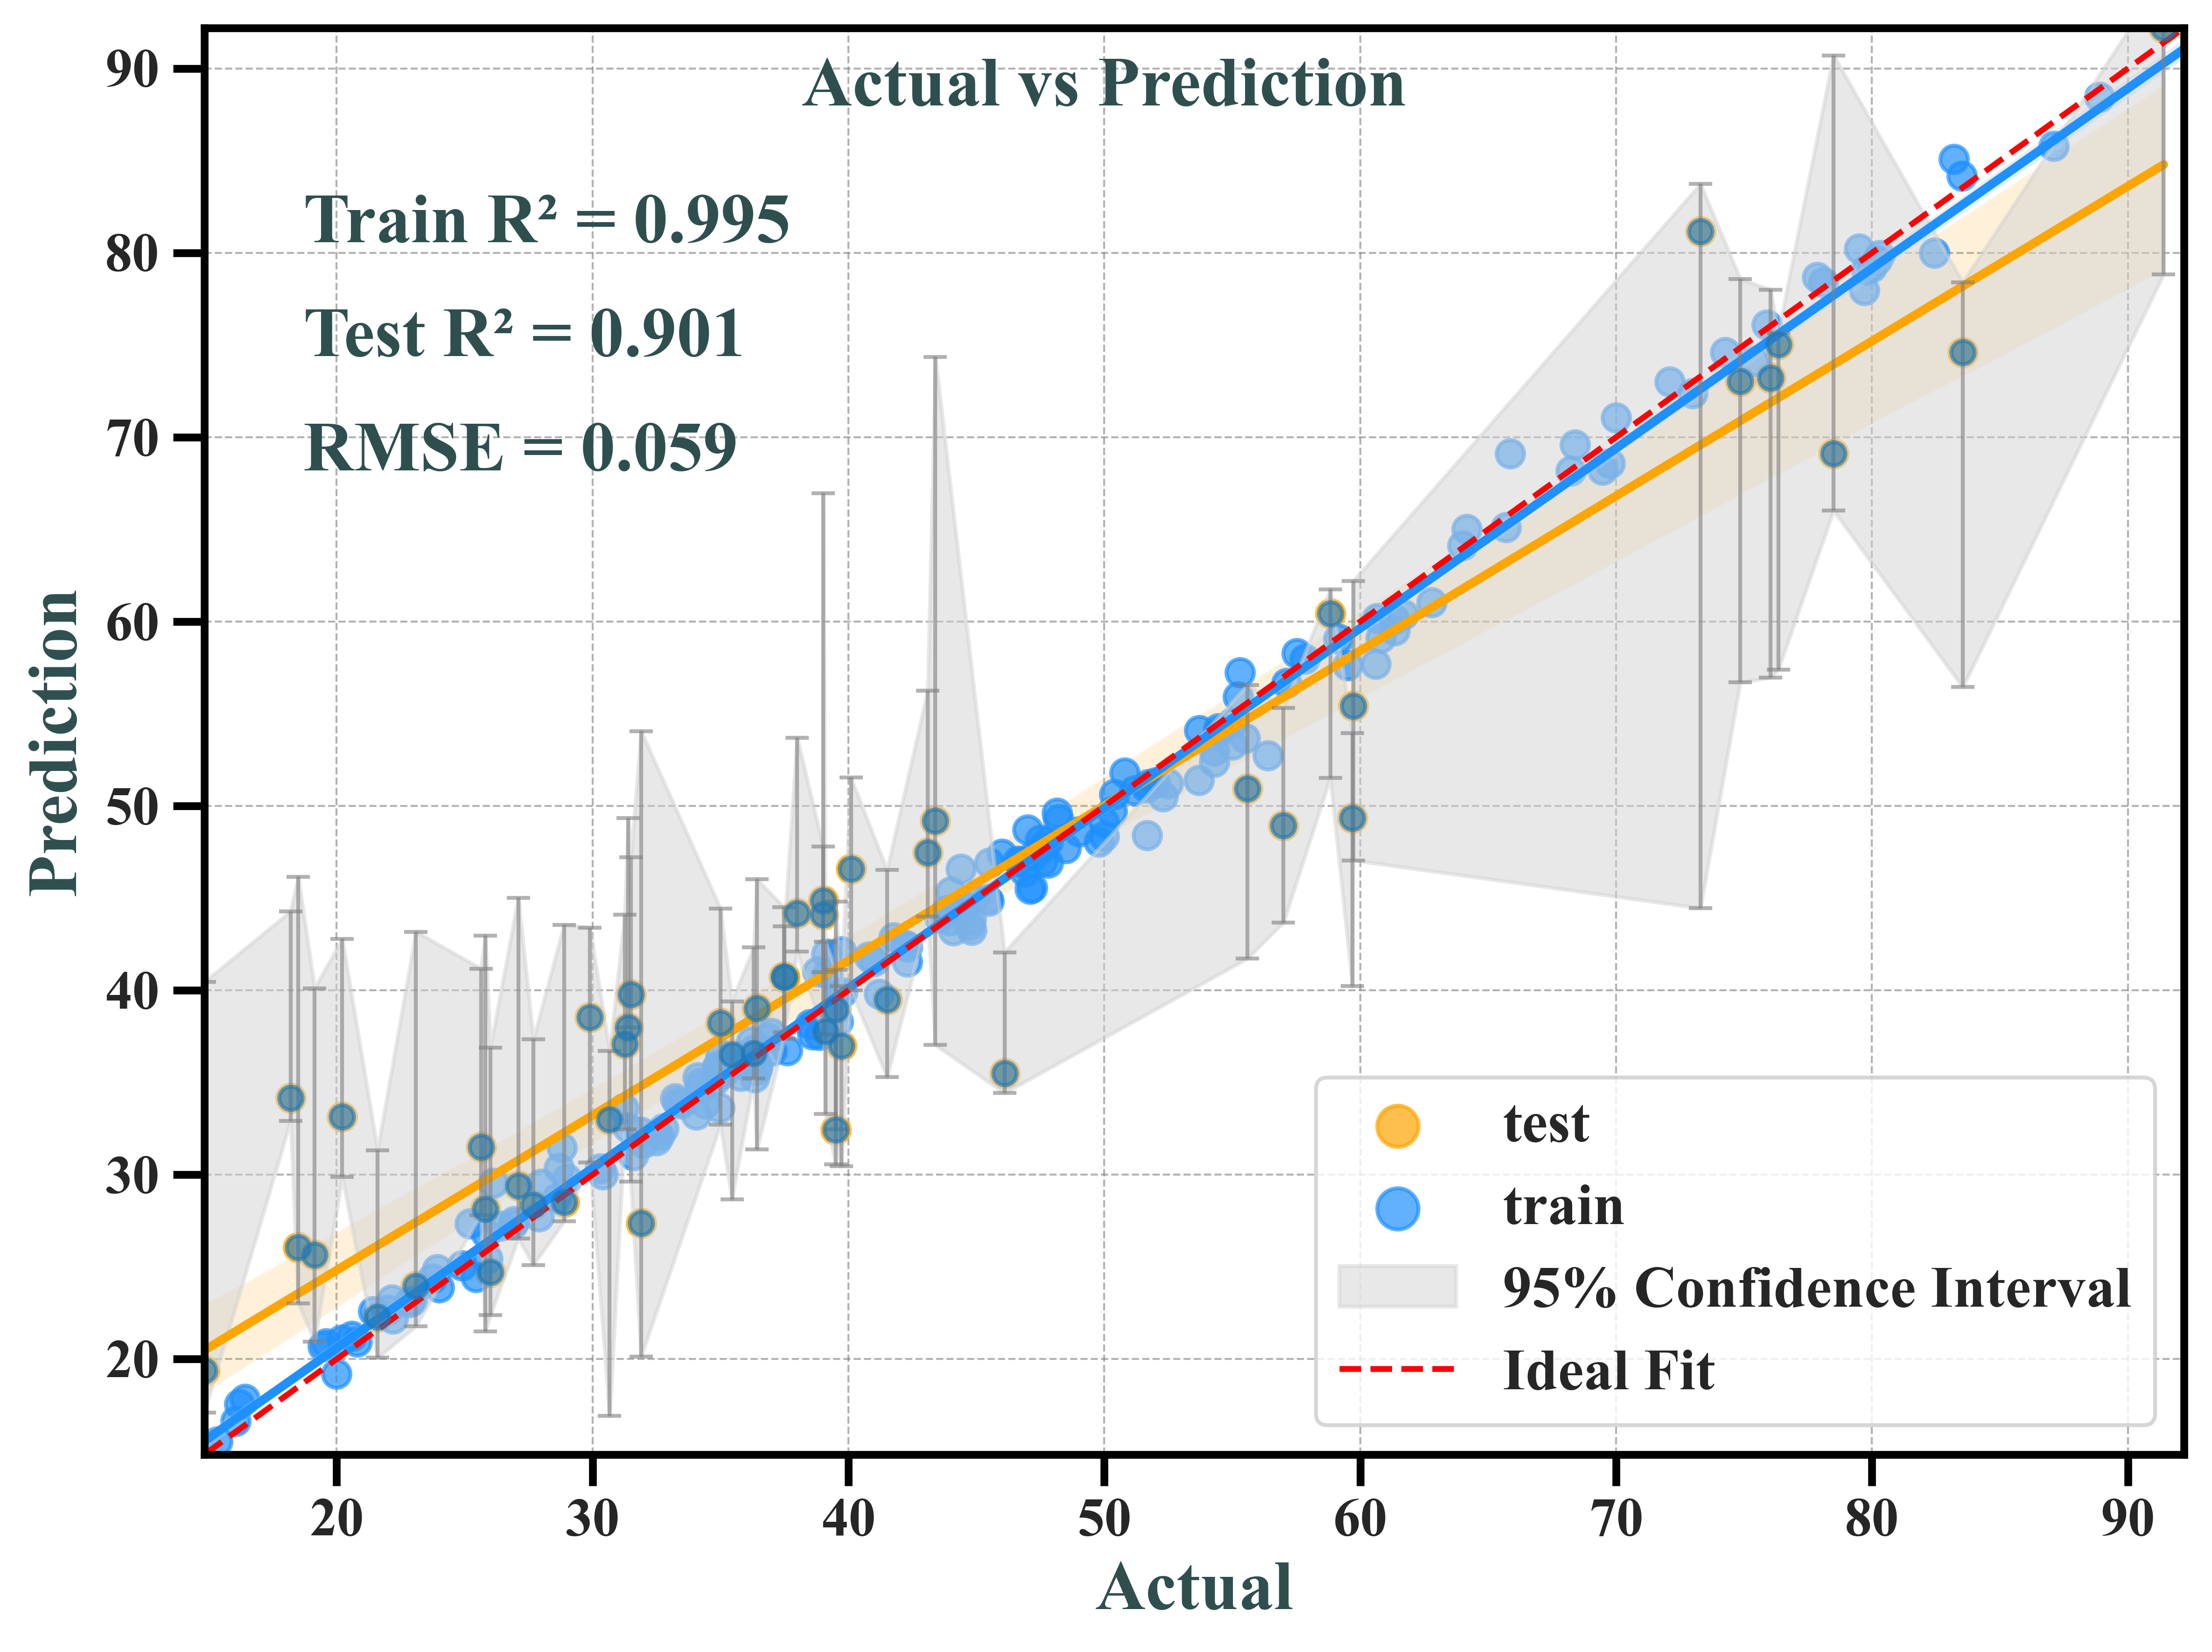

In [169]:
draw_scatter(y_train, train_pred, y_test,test_pred,
                 title = 'Actual vs Prediction',
                 test_lower=lower, test_upper=upper,
                 train_lower=None, train_upper=None,
                 actual_text='Actual', pred_text='Prediction',
                 save=False)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def draw_scatter_nature(train_true, train_pred,
                       test_true, test_pred,
                       mean_pred, test_lower = None, test_upper =None,
                       title):
    plt.rcParams['font.family'] = 'Times New Roman'

    font_common = {
        'family': 'Times New Roman',
        'color': '#2F4F4F',
        'weight': 'bold',
        'size': 18
    }
    # ===== 1. 数据处理 =====
    train_true = np.ravel(train_true)
    train_pred = np.ravel(train_pred)
    test_true = np.ravel(test_true)
    test_pred = np.ravel(test_pred)
    mean_pred = np.ravel(mean_pred)
    lower = np.ravel(test_lower)
    upper = np.ravel(test_upper)

    # ===== 2. 画布 =====
    plt.figure(figsize=(8, 6), dpi=600)
    plt.rcParams['font.family'] = 'Arial'
    # ===== 绘制置信区间阴影 =====
    plt.fill_between(
        test_true_sorted,         # 横坐标为排序后的测试值
        lower_sorted,             # 置信区间下限
        upper_sorted,             # 置信区间上限
        color='lightgray',        # 置信区间颜色
        alpha=0.5,                # 透明度
        label='95% Confidence Interval'  # 图例标签
    )
    # ===== 4. 散点（核心）=====
    plt.scatter(train_true, train_pred,
                color='#1f77b4',
                s=30,
                alpha=0.8,
                label='Train')

    plt.scatter(test_true, test_pred,
                color='#ff7f0e',
                s=35,
                alpha=0.9,
                label='Test')

    # ===== 5. 回归线（干净版）=====
    sns.regplot(x=train_true, y=train_pred,
                scatter=False,
                color='#1f77b4',
                line_kws={'linewidth':2})

    sns.regplot(x=test_true, y=test_pred,
                scatter=False,
                color='#ff7f0e',
                line_kws={'linewidth':2})

    # ===== 6. 误差棒（重点：替代CI阴影）=====
    plt.errorbar(test_true, mean_pred,
                 yerr=[mean_pred - lower, upper - mean_pred],
                 fmt='none',
                 ecolor='#ff7f0e',
                 alpha=0.4,
                 elinewidth=1)

    # ===== 7. 坐标轴 =====
    plt.xlim(0, 100)
    plt.ylim(0, 100)

    plt.xlabel("Actual", fontsize=14)
    plt.ylabel("Predicted", fontsize=14)

    # ===== 以下保持你原有代码 =====
    plt.xlabel(actual_text, fontdict=font_common, weight='bold')
    plt.ylabel(pred_text, fontdict=font_common, weight='bold')

    # 统一坐标范围（与理想拟合线一致）
    plt.xlim(min_val, max_val)
    plt.ylim(min_val, max_val)

    legend_font = {'family': 'Times New Roman', 'weight': 'bold', 'size': 15}
    plt.legend(loc="upper left", markerscale=1.5, prop=legend_font, frameon=True, bbox_to_anchor=(1, 1))

    # 设置坐标轴
    ax = plt.gca()
    ax.tick_params(axis='both', which='major', direction='out', length=8, width=2, color='black', labelsize=14, bottom=True, left=True, top=False, right=False)
    ax.set_facecolor('white')

    for spine in ax.spines.values():
        spine.set_linewidth(2)
        spine.set_edgecolor('black')

    # 显示网格
    plt.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.6)

    # ===== 显示统计信息 =====
    _, _, _, _, _, train_r2 = get_mse_rmse_mae_mape_smape_r2(train_true.values.ravel() / 100, train_pred / 100)
    _, test_rmse, _, _, _, test_r2 = get_mse_rmse_mae_mape_smape_r2(test_true.ravel() / 100, test_pred / 100)
    # ===== 保存图像 =====
    if save:
        out_put = 'scatter_images'
        if not os.path.exists(out_put):
            os.makedirs(out_put)
        output_path = os.path.join(out_put, f'{title}.jpg')
        plt.savefig(output_path, dpi=600, bbox_inches="tight", pil_kwargs={'quality': 95})

    # 设置标题和统计信息的显示位置
    plt.text(50, 75, f"Train R² = {(int(train_r2 * 1000) / 1000):.3f}", **font_common)
    plt.text(50, 65, f"Test R² = {test_r2:.3f}", **font_common)
    plt.text(50, 55, f"RMSE = {test_rmse:.3f}", **font_common)
    plt.text(50, 85, title, **font_common, horizontalalignment="center")


    plt.tight_layout()
    plt.show()